**회귀 문제 예제**
- 학생의 공부 시간에 따른 시험 점수 예측

In [ ]:
# 0단계 : 라이브러리 불러오기
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

# 데이터 준비
- 학생이 공부한 시간을 입력 받아, 시험 점수를 예측.
  - 입력 데이터(x) : 공부 시간(시간)
  - 출력 데이터(y) : 시험 점수(0~100점)

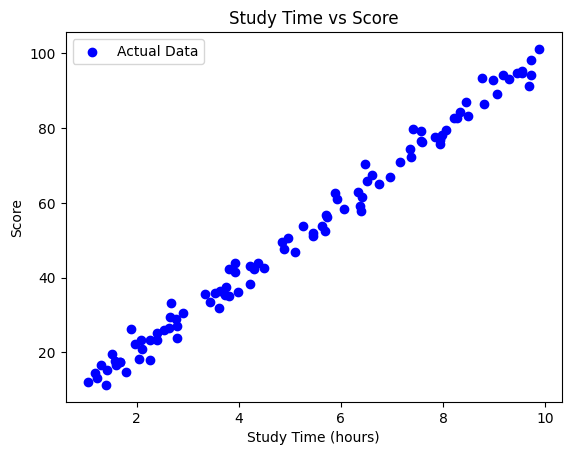

In [ ]:
# 1단계 : 데이터 준비 (공부 시간과 시험 점수)

np.random.seed(42)
X = np.random.uniform(1,10,size=(100,1)) # 공부시간 (1,10시간)
y = 10*X+np.random.normal(0,3,size=(100,1)) # 점수 = 10 *공부시간+노이즈

# 데이터 시각화
plt.scatter(X,y,color='blue',label='Actual Data')
plt.xlabel('Study Time (hours)')
plt.ylabel('Score')
plt.title('Study Time vs Score')
plt.legend()
plt.show()

# 데이터셋 분리 (학습 : 검증 = 80:20)
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 모델 설계

=> 모델 구조

- input layer : 1개의 특성(공부 시간)
- hidden layer : 노드 32개 , 활성화 함수 ReLU
- output layer : 1개의 출력 (시험 점수)

In [ ]:
# 2단계 : 딥러닝 모델 정의

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32,activation='relu',input_shape=(1,)), # 은닉층
    tf.keras.layers.Dense(1) # 출력층
    ])

# 컴파일

옵티마이저와 손실 함수

- **옵티마이저** : Adam
- **손실 함수** : 평균제곱오차(MSE)
- metrics = ['mae']는 TensorFlow/Keras 모델에서 학습 및 평가 과정 중 추가적인 평가 지표로 Mean Absolute Error **( MAX ,평균 절대 오차 )**를 계산하도록 설정

In [ ]:
# 3단계 : 컴파일
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
print('컴파일 완료!')

컴파일 완료!


# 학습

학습 설정
- 에포크 : 100
- 배치 크기 : 16

In [ ]:
# 4단계 : 학습
history = model.fit(X_train , y_train , epochs=100,batch_size=16,validation_split=0.2)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 776.0284 - mae: 23.8611 - val_loss: 1010.1627 - val_mae: 28.8821
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 729.2609 - mae: 23.2073 - val_loss: 982.3654 - val_mae: 28.4606
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 611.0476 - mae: 21.0416 - val_loss: 955.5337 - val_mae: 28.0480
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 696.2255 - mae: 22.7556 - val_loss: 928.6154 - val_mae: 27.6280
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 715.0240 - mae: 23.1200 - val_loss: 901.8618 - val_mae: 27.2045
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 559.8638 - mae: 19.9972 - val_loss: 876.5750 - val_mae: 26.7982
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 535.2321 - mae: 19.5912 - val_loss: 851.6601 - val_mae: 26.3920
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 535.7544 - mae: 19.1716 - val_loss: 826.8856 - val_mae: 25.9820
Epoch 9/100
4/4 ━━━━━━━

# 모델 평가
- 테스트 데이터로 모델 성능 확인

In [ ]:
# 5단계 : 모델 평가

loss,mae = model.evaluate(X_test,y_test)
print(f'Test loss (MSE) : {loss:.2f}')
print(f'test Mean Absolute Error (MAE) : {mae:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 22.1459 - mae: 3.5445
Test loss (MSE) : 22.15
test Mean Absolute Error (MAE) : 3.54


#  예측
- 새로운 공부 시간을 입력으로 받아 시험 점수를 예측

In [ ]:
# 6단계 : 새로운 데이터 예측

new_Study_times = np.array([[5],[7],[9]]) # 새로운 공부 시간
predicted_scores = model.predict(new_Study_times)

# 예측 결과 출력
for time , score in zip(new_Study_times.flatten(),predicted_scores.flatten()):
    print(f'{time} 시간 공부 시 점수 : {score:.1f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
5 시간 공부 시 점수 : 49.1
7 시간 공부 시 점수 : 66.1
9 시간 공부 시 점수 : 83.1


# 결과 시각화
- 학습 곡선 : 학습고 검증 손실(MSE)의 변화를 확인

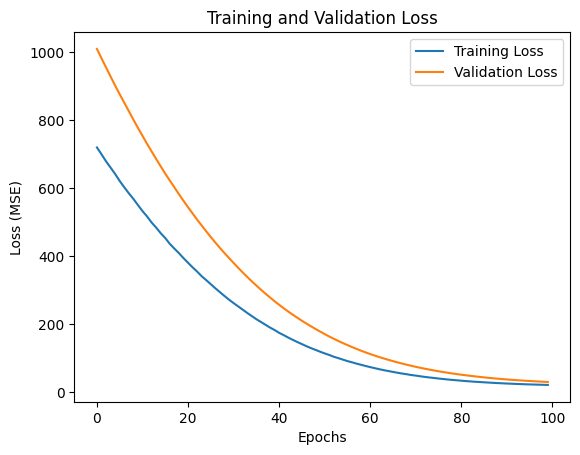

In [ ]:
# 결과 시각화 (테스트 데이터와 예측 데이터 시각화 결과)
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


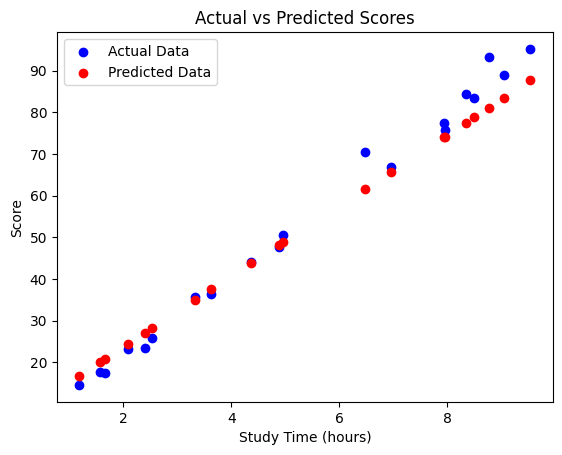

In [ ]:
# 결과 시각화2

y_pred = model.predict(X_test)

plt.scatter(X_test,y_test,color='blue',label='Actual Data')
plt.scatter(X_test,y_pred,color='red', label='Predicted Data')
plt.xlabel('Study Time (hours)')
plt.ylabel('Score')
plt.title('Actual vs Predicted Scores')
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - loss: 3281.5955 - mae: 50.5922 - val_loss: 4322.4380 - val_mae: 61.1857
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3052.2454 - mae: 49.3076 - val_loss: 4311.2085 - val_mae: 61.0985
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2979.2341 - mae: 48.4644 - val_loss: 4299.3955 - val_mae: 61.0071
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3208.2898 - mae: 50.2173 - val_loss: 4286.9961 - val_mae: 60.9116
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3116.3008 - mae: 49.5747 - val_loss: 4274.5386 - val_mae: 60.8153
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 3009.3884 - mae: 48.1629 - val_loss: 4261.8750 - val_mae: 60.7163
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2925.1816 - mae: 47.4011 - val_loss: 4248.8994 - val_mae: 60.6137
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 3519.1003 - mae: 52.6267 - val_loss: 4234.7783 - val_mae: 60.5025
Epoch 9

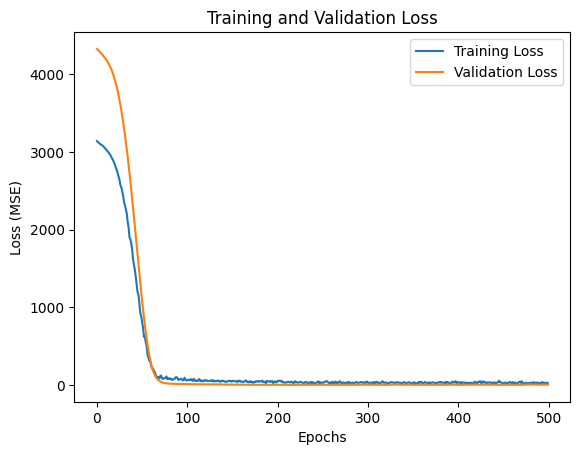

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


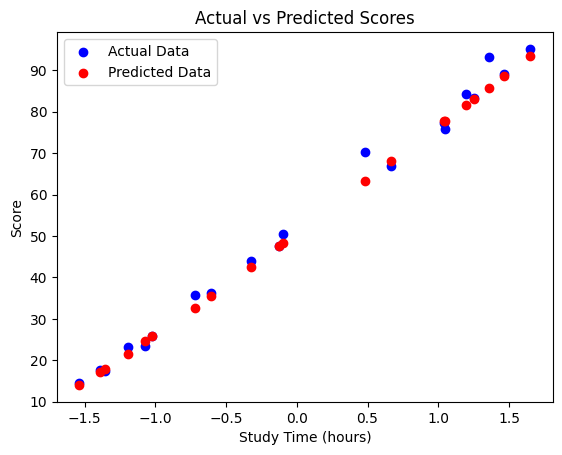

In [ ]:
# 모델 성능 향상
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# 데이터 준비 (공부 시간과 시험 점수)

np.random.seed(42)
X = np.random.uniform(1,10,size=(100,1)) # 공부시간 (1,10시간)
y = 10*X+np.random.normal(0,3,size=(100,1)) # 점수 = 10 *공부시간+노이즈

# 데이터셋 분리 (학습 : 검증 = 80:20)
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 딥러닝 모델 정의

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32,activation='relu',input_shape=(1,)), # 은닉층
    tf.keras.layers.Dropout(0.2), #Dropout 추가
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1) # 출력층
    ])

# 컴파일
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

# 모델 학습
history = model.fit(X_train , y_train , epochs=500,batch_size=16,validation_split=0.2)

# 평가
loss,mae = model.evaluate(X_test,y_test)
print(f'Test loss (MSE) : {loss:.2f}')
print(f'test Mean Absolute Error (MAE) : {mae:.2f}')

# new 데이터 예측

new_Study_times = np.array([[5],[7],[9]]) # 새로운 공부 시간
new_Study_times = scaler.transform(new_Study_times) # 데이터 정규화
predicted_scores = model.predict(new_Study_times)

# 예측 결과 출력
for time , score in zip(new_Study_times.flatten(),predicted_scores.flatten()):
    print(f'{time} 시간 공부 시 점수 : {score:.1f}')

# 결과 시각화
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# 결과 시각화2

y_pred = model.predict(X_test)

plt.scatter(X_test,y_test,color='blue',label='Actual Data')
plt.scatter(X_test,y_pred,color='red', label='Predicted Data')
plt.xlabel('Study Time (hours)')
plt.ylabel('Score')
plt.title('Actual vs Predicted Scores')
plt.legend()
plt.show()

Epoch 1/500


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 3072.9763 - mae: 48.7596 - val_loss: 4314.9502 - val_mae: 61.1621
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3377.9597 - mae: 51.7053 - val_loss: 4301.8047 - val_mae: 61.0750
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2832.8879 - mae: 47.3940 - val_loss: 4289.5156 - val_mae: 60.9929
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 3276.0525 - mae: 51.1343 - val_loss: 4276.6680 - val_mae: 60.9066
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3000.7222 - mae: 48.8096 - val_loss: 4263.9268 - val_mae: 60.8201
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 2743.0710 - mae: 46.4379 - val_loss: 4250.8457 - val_mae: 60.7306
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2987.8013 - mae: 48.0231 - val_loss: 4237.0029 - val_mae: 60.6353
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2743.0789 - mae: 46.1981 - val_loss: 4222.6289 - val_mae: 60.5358
Epoch 9/500
4/4 ━━━━

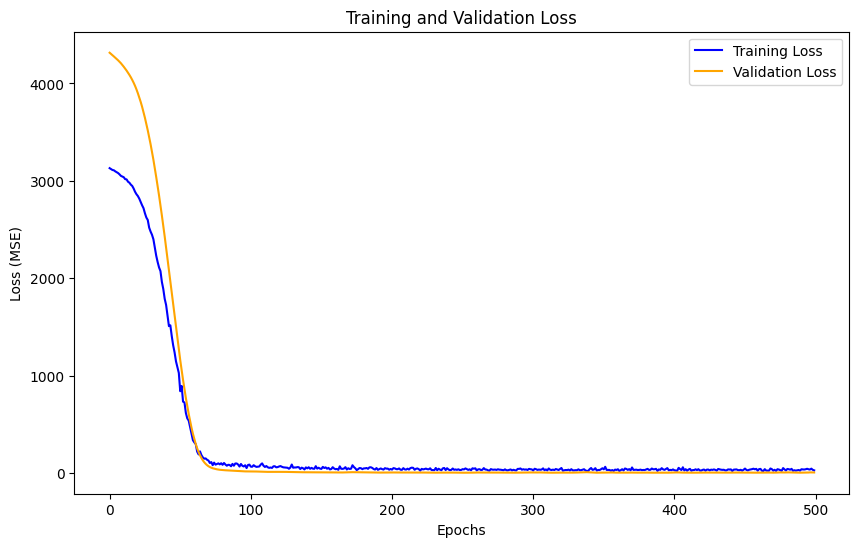

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


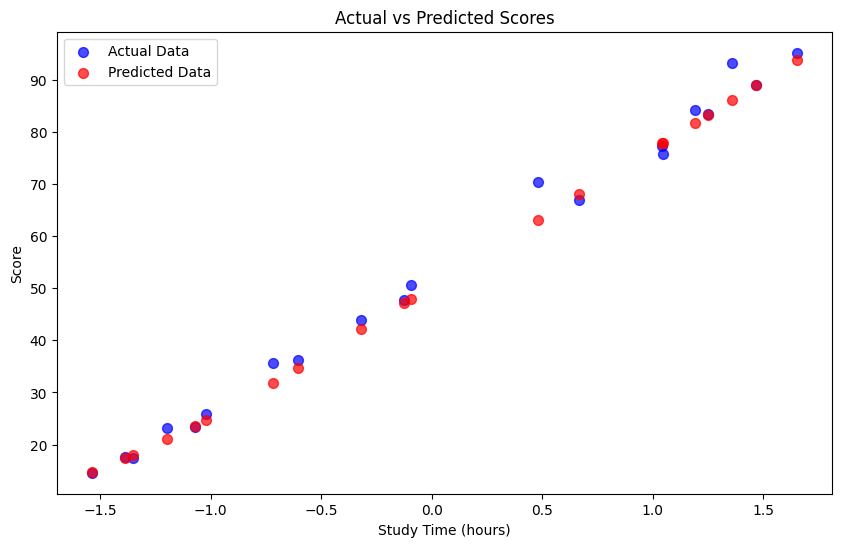

In [ ]:
# 1. 필요한 모듈 임포트
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# 2. 데이터 준비 (공부 시간과 시험 점수)
np.random.seed(42)
X = np.random.uniform(1, 10, size=(100, 1))  # 공부 시간 (1~10시간)
y = 10 * X + np.random.normal(0, 3, size=(100, 1))  # 점수 = 10 * 공부 시간 + 노이즈

# 3. 데이터셋 분리 (학습 : 검증 = 80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 데이터 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. 딥러닝 모델 정의
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(1,)),  # 은닉층 1
    tf.keras.layers.Dropout(0.2),  # 드롭아웃
    tf.keras.layers.Dense(32, activation='relu'),  # 은닉층 2
    tf.keras.layers.Dense(1)  # 출력층
])

# 6. 모델 컴파일
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 7. 모델 학습
history = model.fit(X_train, y_train, epochs=500, batch_size=16, validation_split=0.2, verbose=1)

# 8. 평가
loss, mae = model.evaluate(X_test, y_test)
print(f'Test Loss (MSE): {loss:.2f}')
print(f'Test Mean Absolute Error (MAE): {mae:.2f}')

# 9. 새로운 데이터 예측
new_study_times = np.array([[5], [7], [9]])  # 새로운 공부 시간
new_study_times_scaled = scaler.transform(new_study_times)  # 데이터 정규화
predicted_scores = model.predict(new_study_times_scaled)

# 예측 결과 출력
for time, score in zip(new_study_times.flatten(), predicted_scores.flatten()):
    print(f'{time}시간 공부 시 예상 점수: {score:.1f}')

# 10. 학습 과정 시각화
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# 11. 테스트 데이터 예측 결과 시각화
y_pred = model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data', alpha=0.7, s=50)
plt.scatter(X_test, y_pred, color='red', label='Predicted Data', alpha=0.7, s=50)
plt.xlabel('Study Time (hours)')
plt.ylabel('Score')
plt.title('Actual vs Predicted Scores')
plt.legend()
plt.show()